# Nowcasting Autoencoder Tutorial

Creating an effective autoencoder is a great first step in developing a predictive model. Learning how to create a high-quality latent state is critical, and can later be used to train a new encoder for a pre-existing predictive model, or a new decoder. An example for this could be training an encoder which uses different or fewer variables than the original model. Another might be training a higher-resolution decoder which is capable of producing higher-resolution predictions from the same latent state.

Autoencoders are also a great concept to learn when understanding neural network architectures.

In this example, we first blend radar and satellite data onto the same grid, then train an autoencoder to perform dimensionality reduction and produce a useful latent state which can be used to resonstruct the original inputs.

In [1]:
import datetime

In [2]:
import numpy as np

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe


In [5]:
import warnings
warnings.filterwarnings('ignore')

Set the data accessor to the accessor that is appropriate for your site. 
* NCI - `import site_archive_nci`
* JASMIN `import site_archive_jasmin`
* Met Office - `import site_archive_met_office`

In [6]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/ssde/j25a/mmh_storage/theme3/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/ssde/j25a/mmh_storage/theme3/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/ssde/j25a/mmh_storage/theme3/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar'}


In [7]:
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

In [9]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Load and prepare data

To load and prepare the data, we will use the PyEarthTools site accessor, and then build a pipeline with the data accessor to do the necessary transforms to prepare the data for training an autoencoder.

PyEarthTools API docs
* [Data API Index](https://pyearthtools.readthedocs.io/en/latest/api/data/data_index.html)
* [Archive Index Class docs](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.indexes.ArchiveIndex)
* [Example ERA5 accessor](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.download.weatherbench.WB2ERA5)

In [10]:
# We specify the date, hour, and minute for querying data
selected_date = datetime.datetime(2021,6,9,2,0)

In [11]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

In [12]:
himawari[selected_date]

<xarray.Dataset> Size: 31MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T02:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:08 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [13]:
rf3proj = petdata.transforms.projection.Rainfields3ProjAus()
radar_projector = petdata.transforms.projection.XYtoLonLatRectilinear(rf3proj)

We can start with a simple pipeline and then demonstrate how to use it.

In [14]:

satpipe = petpipe.Pipeline(
    himawari
)

In [15]:
himawari_sample = satpipe['20210609T0200']
himawari_sample

<xarray.Dataset> Size: 31MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T02:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:08 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

### Defining the pipeline
Now we will add in all the processing steps we need, including:
* order the coordinates to be suitable and optimised to accessed by the iterator.
* Select a subset based on latitude and longitude
* Convert to numpy
* specify the range an iterator on the pipeline should walkthrough

PyEarthools API Docs
* [Pipeline Class](https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_api.html#pyearthtools.pipeline.Pipeline)
* [Pipeline operations docs](https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_api.html#pipeline-operations)

In [16]:
fullsat = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20200101T00', '20200301T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)


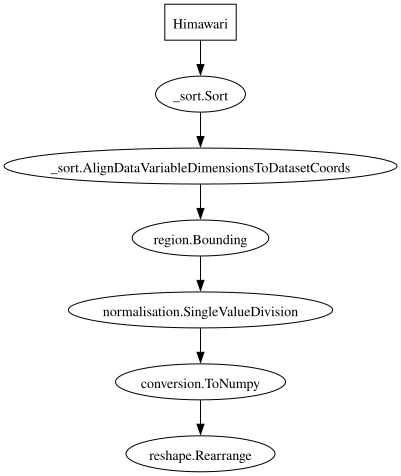

In [17]:
fullsat

### Data Exploration
Lets take a look at what the dataset contains. For this purpose we will create a smaller pipeline that keeps the data in xarray for easier plotting.

In [18]:
eda_pipeline = petpipe.Pipeline(
    satpipe,
    # GeospatialTimeSeriesMerge(reference_dataset=himawari_sample), # These are pretty similar grids, so just pick one
    # petdata.transforms.variables.Drop(['x_bounds', 'y_bounds', 'proj', 'x', 'y']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    iterator=petpipe.iterators.DateRange('20210101T00', '20210103T00', interval='1 hours'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

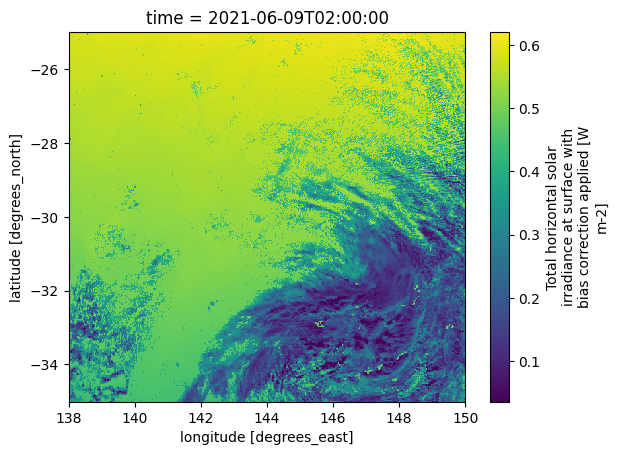

In [19]:
eda_pipeline[selected_date]['surface_global_irradiance'][0,:,:].plot.imshow()

do plot side by side with different times (3 1 hour apart)

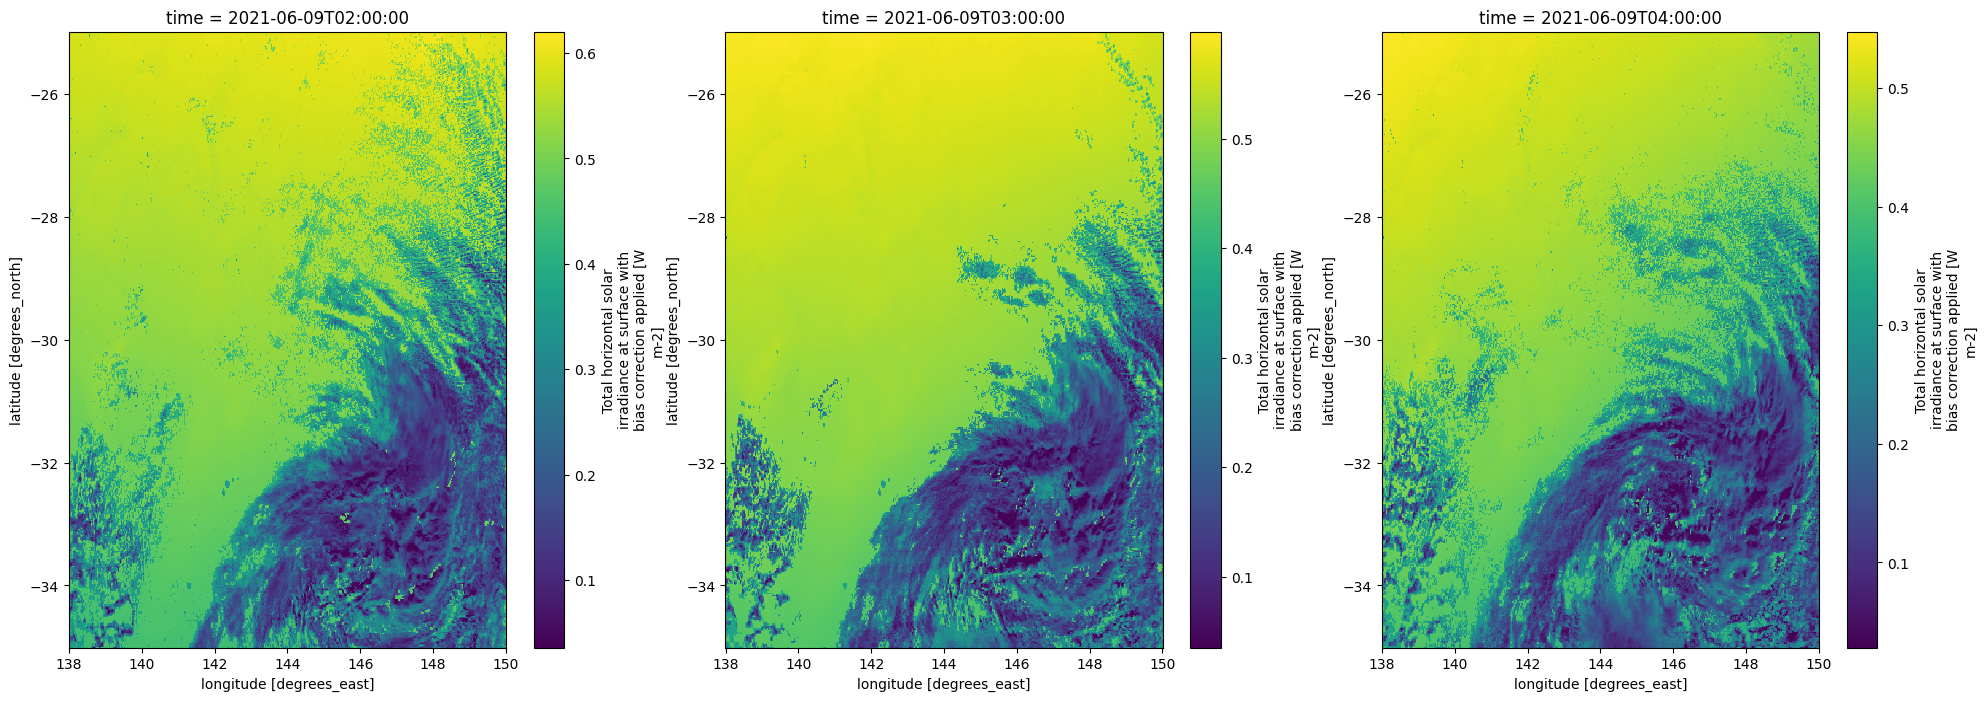

In [20]:
fig1 = plt.figure('sidebyside_satellite', figsize=(24,8))
for ix1 in range(3):
    ax1 = fig1.add_subplot(1,3,ix1+1)
    plot_time = selected_date + datetime.timedelta(hours=ix1)
    eda_pipeline[plot_time]['surface_global_irradiance'][0,:,:].plot.imshow(ax=ax1)


### Creating an iterator
An important function in pyearthtools is the concept of an iterator, which walks through the data. This enables the data to be accessed one batch at a time during the training by accessing the data the iterator points at and then moving on to the next dataset. The iterator is how we will present the data to the ML framework for training.

PyEarthools API Docs
* [PyEarthTools Iterator class](https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_api.html#pyearthtools.pipeline.iterators.Iterator)

In [21]:
eda_sat_iterator = iter(eda_pipeline)  # Make an iterator to walk the time period
eda_sat_iterator

<generator object Pipeline.__iter__ at 0x7f79546e8760>

In [22]:
eda_pipeline.exceptions_to_ignore

(pyearthtools.data.exceptions.DataNotFoundError,)

In [23]:
next_image_from_pipe = next(eda_sat_iterator)
next_image_from_pipe

<xarray.Dataset> Size: 14MB
Dimensions:                    (time: 6, latitude: 501, longitude: 601)
Coordinates:
  * time                       (time) datetime64[ns] 48B 2021-01-01 ... 2021-...
  * latitude                   (latitude) float32 2kB -35.0 -34.98 ... -25.0
  * longitude                  (longitude) float32 2kB 138.0 138.0 ... 150.0
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 14MB dask.array<chunksize=(1, 501, 601), meta=np.ndarray>
Attributes: (12/52)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    bias_correction_applied_meaning:  0: not applied; 1:applied
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

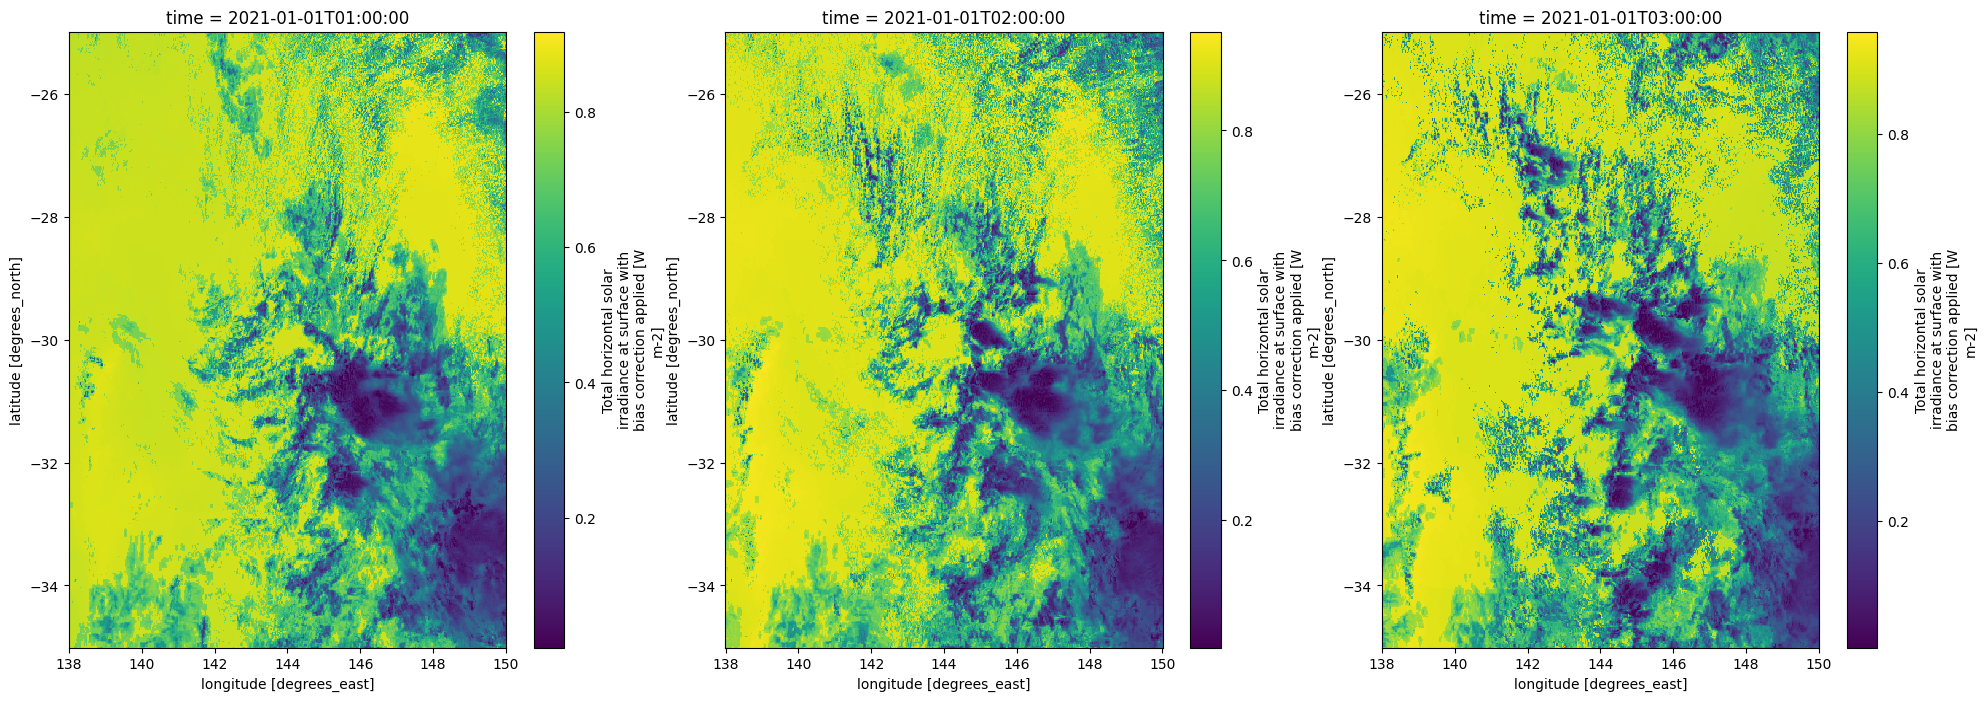

In [24]:
fig1 = plt.figure('sidebyside_satellite', figsize=(24,8))
for ix1 in range(3):
    ax1 = fig1.add_subplot(1,3,ix1+1)
    next_image_from_pipe = next(eda_sat_iterator)
    next_image_from_pipe['surface_global_irradiance'][0,:,:].plot.imshow(ax=ax1)


## Training a machine learning model
Now that we have loaded and prepared the data, we can train a machine learning model on the data using the pipeline to feed the data into the training algorithm. In this example we will use an autoencoder, which is an example of unsupervised training as we don't need to label the data.

### Define the Autoencoder architecture
Here we define an **AutoEncoder**. This is a model which reproduces its inputs, through a bottleneck layer. It is one of the primary concepts behind many  neural network architectures that you will work with in future, and is key to  conceptual understanding as well as being sometimes useful in understanding the dataset.

Further reading
* [Building a Pytorch Model](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)
* [nn.Module docs](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module)
* [Autoencoder tutorial](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/08-deep-autoencoders.html)

In [25]:
# Reminder, the image size is latitude: 1726, longitude: 2214

class AutoEncoder(nn.Module):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super(AutoEncoder, self).__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=stride, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

Having defined a model class, we now create an instance of the class, and send it to the GPU for training purposes.


In [26]:
model = AutoEncoder(input_channel_count=1, output_channel_count=1).to(device)

Specify the loss function and optimiser

In [27]:
# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Prediction from untrained Autoencoder
Here we demonstrate how if we make a prediction before training randomly initialised weights, we get garbage out. 
These code snippets also demonstrate how we move the data into the GPU memory in oder to do inference on the GPU, and then move it back to the CPU to analyse it further.

In [28]:
training_iterator = iter(fullsat)  # Make an iterator to walk the time period
training_iterator

<generator object Pipeline.__iter__ at 0x7f79546e83d0>

In [29]:
sample_numpy = next(training_iterator)
sample_numpy

array([[[[0.73251667, 0.73271667, 0.73290833, ..., 0.53389167,
          0.52780833, 0.513675  ],
         [0.732625  , 0.732825  , 0.73301667, ..., 0.51565833,
          0.51565833, 0.5015    ],
         [0.73284167, 0.73303333, 0.73323333, ..., 0.51574167,
          0.49040833, 0.49040833],
         ...,
         [0.71599167, 0.71619167, 0.71638333, ..., 0.810125  ,
          0.704325  , 0.80504167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80789167,
          0.701475  , 0.80384167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80460833,
          0.80255   , 0.80276667]]]], shape=(1, 1, 501, 601))

In [30]:
def next_sample_gpu(pet_iterator):
    return torch.from_numpy(next(pet_iterator)).float().to(device)

In [31]:
def prediction_from_iterator(pet_iterator, model):
    sample_numpy = next(pet_iterator)
    sample_gpu = torch.from_numpy(sample_numpy).float().to(device)
    prediction_gpu = model.forward(sample_gpu)
    prediction_cpu = sample_prediction_gpu.to('cpu').detach().numpy()
    return prediction_cpu

In [32]:
sample_tensor_gpu = torch.from_numpy(sample_numpy).float().to(device)
sample_tensor_gpu

tensor([[[[0.7325, 0.7327, 0.7329,  ..., 0.5339, 0.5278, 0.5137],
          [0.7326, 0.7328, 0.7330,  ..., 0.5157, 0.5157, 0.5015],
          [0.7328, 0.7330, 0.7332,  ..., 0.5157, 0.4904, 0.4904],
          ...,
          [0.7160, 0.7162, 0.7164,  ..., 0.8101, 0.7043, 0.8050],
          [0.7159, 0.7160, 0.7162,  ..., 0.8079, 0.7015, 0.8038],
          [0.7159, 0.7160, 0.7162,  ..., 0.8046, 0.8026, 0.8028]]]],
       device='cuda:0')

In [33]:
# This should make us a messy prediction from an untrained model in the dimension of the input
sample_prediction_gpu = model.forward(sample_tensor_gpu)
sample_prediction_gpu

tensor([[[[0.5007, 0.4892, 0.5045,  ..., 0.5049, 0.4945, 0.4965],
          [0.4909, 0.4847, 0.4974,  ..., 0.4966, 0.4855, 0.4957],
          [0.5053, 0.4913, 0.5063,  ..., 0.5060, 0.4959, 0.4921],
          ...,
          [0.5057, 0.4916, 0.5063,  ..., 0.5071, 0.4962, 0.4922],
          [0.4947, 0.4827, 0.4993,  ..., 0.4991, 0.4909, 0.4949],
          [0.4967, 0.4934, 0.4926,  ..., 0.4922, 0.4916, 0.4861]]]],
       device='cuda:0', grad_fn=<SigmoidBackward0>)

In [34]:
sample_prediction_gpu = model.forward(next_sample_gpu(training_iterator))
sample_prediction_gpu

tensor([[[[0.5007, 0.4892, 0.5045,  ..., 0.5049, 0.4945, 0.4965],
          [0.4909, 0.4847, 0.4974,  ..., 0.4965, 0.4855, 0.4957],
          [0.5052, 0.4913, 0.5063,  ..., 0.5060, 0.4959, 0.4921],
          ...,
          [0.5057, 0.4916, 0.5063,  ..., 0.5071, 0.4962, 0.4922],
          [0.4947, 0.4827, 0.4993,  ..., 0.4991, 0.4909, 0.4949],
          [0.4967, 0.4934, 0.4926,  ..., 0.4922, 0.4916, 0.4861]]]],
       device='cuda:0', grad_fn=<SigmoidBackward0>)

In [35]:
sample_image_numpy_cpu = sample_prediction_gpu.to('cpu').detach().numpy()
sample_image_numpy_cpu

array([[[[0.50066555, 0.48923492, 0.5044858 , ..., 0.50488853,
          0.49451387, 0.49649027],
         [0.49090624, 0.48472565, 0.49744317, ..., 0.49654698,
          0.4855185 , 0.49566448],
         [0.5052452 , 0.49125722, 0.506305  , ..., 0.5060132 ,
          0.49593255, 0.49208266],
         ...,
         [0.50569075, 0.49159238, 0.50625706, ..., 0.5070591 ,
          0.49621794, 0.4921509 ],
         [0.49466854, 0.48274335, 0.49927363, ..., 0.49906513,
          0.49090406, 0.4949398 ],
         [0.49666557, 0.49339545, 0.49257937, ..., 0.4921879 ,
          0.49162406, 0.4860889 ]]]],
      shape=(1, 1, 501, 601), dtype=float32)

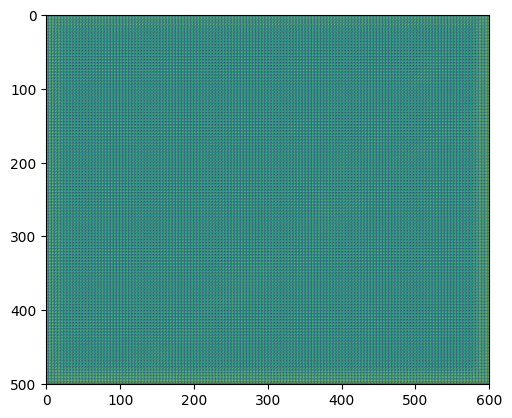

In [36]:
plt.imshow(sample_image_numpy_cpu[0][0])

### Train the autoencoder
Now we define the training loop function and run the training. # 1000 samples is taking about 2 minutes It should be able to go much much much faster, but still we can test it and make progress. Let's to 30 minutes of training, i.e. 15k samples

In [37]:
def train(debug=True, num_epochs=1, max_samples=10, print_per=20, batch_size=16):
    """
    Main Training loop Function
    """
    sample_ix = 0 
    
    
    for epoch in range(num_epochs):
        print(f'current epoch {epoch+1}')
        total_loss = 0    
        epoch_samples = 0
        training_iterator = iter(fullsat)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(training_iterator)
            except StopIteration:
                print('stop')
                break  # advance the epoch loop
            except:
                print('error - general')
                pass # some samples are just missing
    
            sample_ix += batch_size
            epoch_samples += batch_size
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                print('exceeded max samples')
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                # print('skipping nans')
                continue
                
            if debug:
                print("Input")
                print(x)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model.forward(x)

            if debug:
                print("prediction")
                print(y)
            
            loss = criterion(y, x)
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        if epoch_samples != 0:
            avg_loss = total_loss / epoch_samples
            print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')
        else:
            print('no samples processed this epoch')

In [ ]:
%%time
train(debug=False, num_epochs=3, max_samples=15 * 1000, print_per = 500, batch_size=1)

current epoch 1
500


### Make predictions
Once the model is trained, we now make predictions and evaluate the model.

In [49]:
fullsat_validate = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210101T00', '20220101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

In [50]:
validate_iterator = iter(fullsat_validate)

In [51]:
prediction_from_iterator(validate_iterator, model)

array([[[[0.50066555, 0.48923492, 0.5044858 , ..., 0.50488853,
          0.49451387, 0.49649027],
         [0.49090624, 0.48472565, 0.49744317, ..., 0.49654698,
          0.4855185 , 0.49566448],
         [0.5052452 , 0.49125722, 0.506305  , ..., 0.5060132 ,
          0.49593255, 0.49208266],
         ...,
         [0.50569075, 0.49159238, 0.50625706, ..., 0.5070591 ,
          0.49621794, 0.4921509 ],
         [0.49466854, 0.48274335, 0.49927363, ..., 0.49906513,
          0.49090406, 0.4949398 ],
         [0.49666557, 0.49339545, 0.49257937, ..., 0.4921879 ,
          0.49162406, 0.4860889 ]]]],
      shape=(1, 1, 501, 601), dtype=float32)

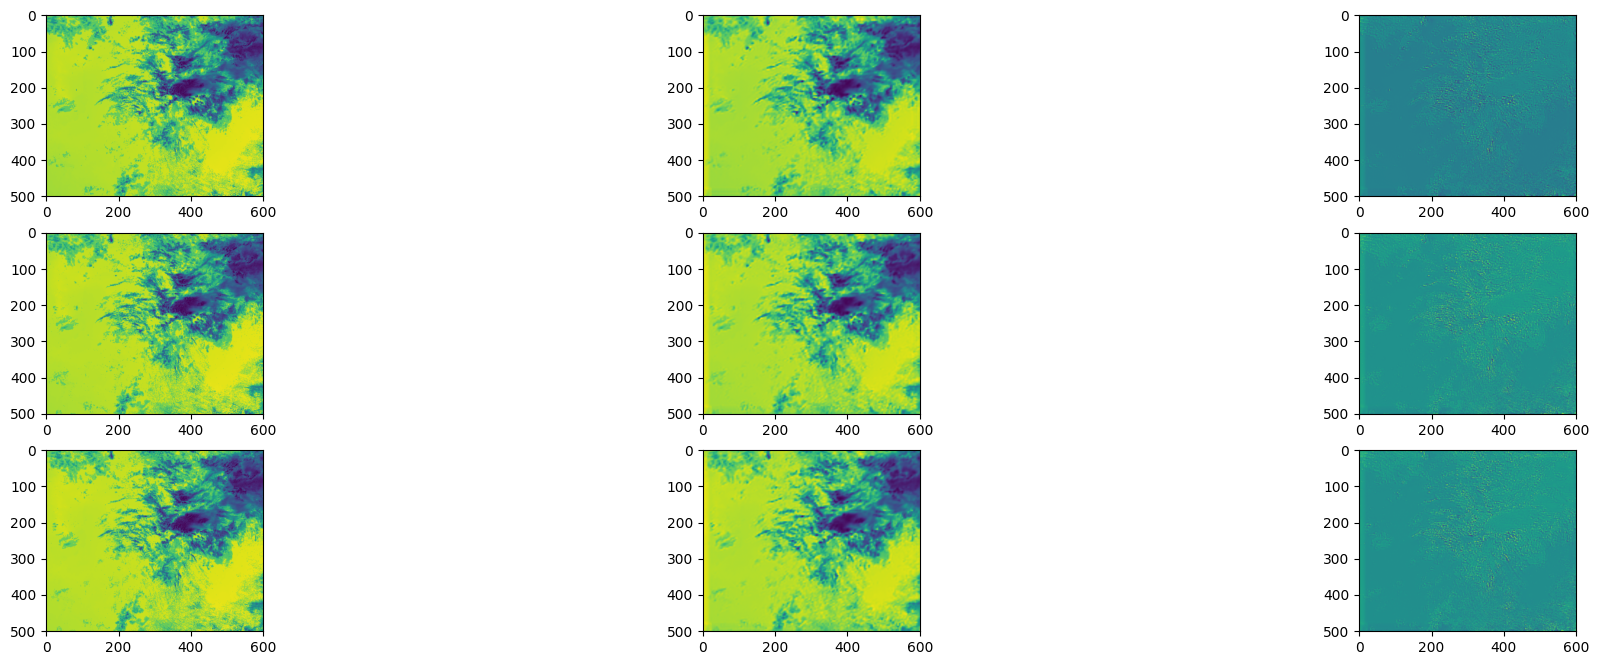

In [52]:
fig1 = plt.figure('sidebyside_satellite', figsize=(24,8))
for ix1 in range(3):
    sample_numpy = next(validate_iterator)
    sample_gpu = torch.from_numpy(sample_numpy).float().to(device)
    prediction_gpu = model.forward(sample_gpu)
    prediction_cpu = prediction_gpu.to('cpu').detach().numpy()
    ax1 = fig1.add_subplot(3,3,(ix1*3)+1)
    ax1.imshow(sample_numpy[0,0])
    ax1 = fig1.add_subplot(3,3,(ix1*3)+2)
    ax1.imshow(prediction_cpu[0,0])
    ax1 = fig1.add_subplot(3,3,(ix1*3)+3)
    ax1.imshow(prediction_cpu[0,0] - sample_numpy[0,0])    

# Calculate scores for predictions
In order to evaluate the model performance, we need to use some metrics that capture different aspects of accuracy. Since we are generating images, we will use various state of the art image-related metrics. 

Furthe reading:
* [Guide to metrics for images generated by ML models](https://huggingface.co/blog/PrunaAI/objective-metrics-for-image-generation-assessment)
* torch metrics
   * [Structural Similarity Index](https://lightning.ai/docs/torchmetrics/stable/image/structural_similarity.html) - Aiming to measure how well the image strcuture is captured
   * [RMSE Sliding Window](https://lightning.ai/docs/torchmetrics/stable/image/root_mean_squared_error_using_sliding_window.html)Look at RMSE, but not just point by point

In [53]:
import torchmetrics.image

In [54]:
ssi_metric = torchmetrics.image.StructuralSimilarityIndexMeasure()

In [55]:
rmse_sw_metric = torchmetrics.image.RootMeanSquaredErrorUsingSlidingWindow()

In [56]:
ssi_values = []
rmse_values = []
for ix1 in range(10):
    sample_numpy = next(validate_iterator)
    sample_cpu = torch.from_numpy(sample_numpy).float()
    sample_gpu = sample_cpu.to(device)
    prediction_gpu = model.forward(sample_gpu)
    prediction_cpu_tensor = prediction_gpu.to('cpu').detach()
    
    ssi_values += [float(ssi_metric(sample_cpu,  prediction_cpu_tensor)) ]
    rmse_values += [float(rmse_sw_metric(sample_cpu,  prediction_cpu_tensor))]

In [57]:
ssi_values

[0.599666953086853,
 0.5938255190849304,
 0.6057079434394836,
 0.5808976292610168,
 0.5494664907455444,
 0.5597828030586243,
 0.5347251892089844,
 0.5212662220001221,
 0.510153591632843,
 0.4967922866344452]

In [58]:
rmse_values

[0.05667933449149132,
 0.06012710556387901,
 0.06275594979524612,
 0.06581048667430878,
 0.0692400112748146,
 0.07177083194255829,
 0.07587534189224243,
 0.07947684079408646,
 0.08317696303129196,
 0.0867389515042305]

### Ideas for extension

* Improved model architecture
  * Compare results for a larger model (more layers, larger latent space)
  * Compare results for different sizes of training dataset
  * Can we incorporate a different loss function more suitable for this application?
* Alternative metrics
  * Are there better ways to measure model performance
* Different datasets
  * Could we use this apporach with other satellite datasets?
  * Could we add more channels?
  * Could we blend with other sources e.g. model data, radar?

### Further reading

* [PyTorch Lightning Autoencoder](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/08-deep-autoencoders.html)
* [PyEarthTools API docs](https://pyearthtools.readthedocs.io/en/latest/api/api.html)
